# Business Understanding

## Project Domain

Proyek ini bertujuan untuk membangun model machine learning yang dapat memprediksi waktu pengiriman makanan secara akurat berdasarkan berbagai faktor seperti jarak, waktu pemesanan, kondisi restoran, dan kondisi lalu lintas. Prediksi waktu pengiriman yang akurat dapat meningkatkan kepuasan pelanggan dan membantu restoran mengelola operasi pengiriman dengan lebih efisien.

## Problem Statements

1. Meningkatkan kepuasan pelanggan dengan menyediakan perkiraan waktu pengiriman yang lebih akurat dan reliabel.
2. Meningkatkan efisiensi operasional restoran dan kurir dengan informasi waktu pengiriman yang lebih tepat, mengurangi penumpukan pesanan dan waktu tunggu yang tidak perlu.
3. Meminimalisir pembatalan pesanan akibat ketidakpuasan pelanggan terhadap waktu tunggu.
4. Memberikan wawasan data yang berharga bagi pengambilan keputusan bisnis terkait strategi operasional dan logistik.

## Goals

Pengembangan model prediksi waktu pengiriman makanan yang akurat dan real-time berdasarkan faktor-faktor seperti:
1. Jarak antara restoran dan pelanggan.
2. Waktu pemesanan dan waktu pengiriman.
3. Kondisi lalu lintas di area pengiriman.
4. Jumlah pesanan yang sedang diproses oleh restoran dan kurir.
5. Cuaca.
6. Jenis dan jumlah makanan yang dipesan.

## Solution Statements

Model machine learning yang dilatih dengan data historis pengiriman makanan, seperti waktu pemesanan, detail restoran, lokasi pelanggan, dan kondisi lalu lintas, dapat digunakan untuk memprediksi waktu pengiriman makanan di masa mendatang. Model ini dapat diintegrasikan ke dalam platform pemesanan online atau aplikasi seluler untuk memberikan estimasi waktu pengiriman yang akurat kepada pelanggan dan restoran

# Data Understanding

## Import data dari kaggle

In [14]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"ofigure","key":"bdcda8d23ad9bb94c50726ecd422c889"}'}

In [15]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [16]:
!kaggle datasets download -d denkuznetz/food-delivery-time-prediction

Dataset URL: https://www.kaggle.com/datasets/denkuznetz/food-delivery-time-prediction
License(s): apache-2.0
food-delivery-time-prediction.zip: Skipping, found more recently modified local copy (use --force to force download)


In [17]:
!kaggle datasets download -d denkuznetz/food-delivery-time-prediction
!unzip food-delivery-time-prediction.zip -d food-delivery-time-prediction
!ls food-delivery-time-prediction

Dataset URL: https://www.kaggle.com/datasets/denkuznetz/food-delivery-time-prediction
License(s): apache-2.0
food-delivery-time-prediction.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  food-delivery-time-prediction.zip
replace food-delivery-time-prediction/Food_Delivery_Times.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: Food_Delivery_Times.csv


## Import Library yang dibutuhkan

In [53]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPRegressor

In [19]:
df = pd.read_csv("food-delivery-time-prediction/Food_Delivery_Times.csv")
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [20]:
df.info(), df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


(None,
           Order_ID  Distance_km  Preparation_Time_min  Courier_Experience_yrs  \
 count  1000.000000  1000.000000           1000.000000              970.000000   
 mean    500.500000    10.059970             16.982000                4.579381   
 std     288.819436     5.696656              7.204553                2.914394   
 min       1.000000     0.590000              5.000000                0.000000   
 25%     250.750000     5.105000             11.000000                2.000000   
 50%     500.500000    10.190000             17.000000                5.000000   
 75%     750.250000    15.017500             23.000000                7.000000   
 max    1000.000000    19.990000             29.000000                9.000000   
 
        Delivery_Time_min  
 count        1000.000000  
 mean           56.732000  
 std            22.070915  
 min             8.000000  
 25%            41.000000  
 50%            55.500000  
 75%            71.000000  
 max           153.000000  )

## Exploratory Data Analysis

In [21]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns

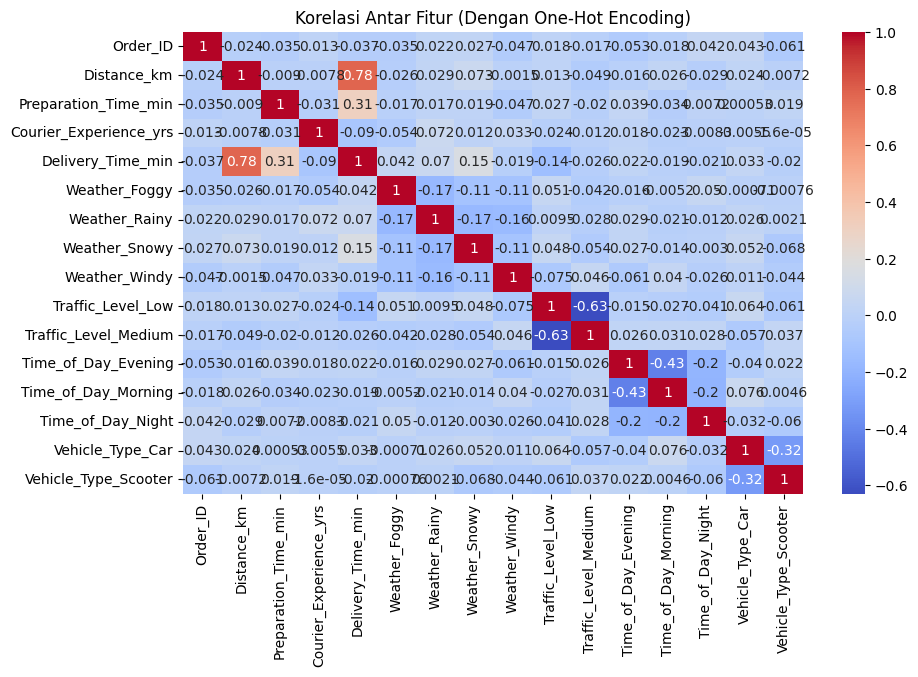

In [22]:
# Convert categorical columns into numeric form (One-Hot Encoding)
df_encoded = pd.get_dummies(df, drop_first=True)

# Visualization of correlation between numeric features with target Delivery_Time_min
plt.figure(figsize=(10, 6))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.title("Korelasi Antar Fitur (Dengan One-Hot Encoding)")
plt.show()

penjelasan categorial :

1.   Delivery Distance (Distance_km) and Delivery Time (Delivery_Time_min): The correlation of 0.78 between Distance_km and Delivery_Time_min shows a very strong relationship between delivery distance and delivery time. This means that the farther the shipping distance, the longer it will take for delivery. This is a very important insight for estimating delivery times based on distance.
2.   Weather (Weather): Weather has very low correlation with almost all other features, indicating that weather conditions have little direct influence on other variables such as delivery time or distance. However, a slight effect is seen on Time_of_Day and Vehicle_Type.
3.   Traffic Level (Traffic_Level): Traffic_Level also shows low correlation with other variables, but has a moderate correlation with Delivery_Time_min (0.19). This shows that traffic conditions slightly influence delivery times, although not as strongly as the distance factor.
4.   Time of Day (Time_of_Day): Time_of_Day has a very weak correlation with Delivery_Time_min, indicating that delivery time (morning, afternoon, evening) does not affect delivery time significantly.
5.   Vehicle Type (Vehicle_Type): Vehicle_Type shows very low correlation with Delivery_Time_min and Traffic_Level, but slightly higher with Weather and Time_of_Day. This suggests that vehicle type may be more related to factors such as weather conditions or time of day, rather than delivery times or traffic.
6.   Preparation Time (Preparation_Time_min): Preparation_Time_min has a moderate correlation with Delivery_Time_min (0.31), indicating that preparation time influences total delivery time. The longer the preparation time, the longer it will take for delivery.
7.   Courier Experience (Courier_Experience_yrs): Courier_Experience_yrs has very low correlation with other features, indicating that courier experience does not have a large influence on delivery times in this dataset.

# Conclusion :
This heatmap provides a clear picture that delivery distance is a major factor in determining delivery time, with preparation time and traffic also contributing significantly. Companies can focus on optimizing routes and lead times to increase delivery speeds and utilize traffic and weather information to reduce uncertainty in delivery time estimates.


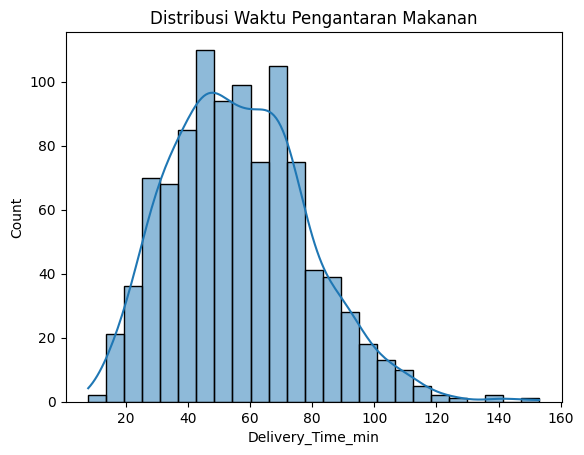

In [23]:
# Delivery_Time_min distribution visualization
sns.histplot(df['Delivery_Time_min'], kde=True)
plt.title("Distribusi Waktu Pengantaran Makanan")
plt.show()

1. Distribution Pattern: The distribution of food delivery times tends to be normal or almost symmetrical with a peak in the 40-60 minute range. This shows that most deliveries are completed within that time frame.

2. Number of Deliveries on Average Time: The majority of deliveries occur within a time frame of around 50-70 minutes, with some fluctuation, indicating that the average delivery time is usually around that figure.

3. Outliers: There are outliers or longer deliveries, especially on the right side of the histogram, above 100 minutes. This indicates that some deliveries are taking longer than usual. This can be caused by various factors, such as traffic jams, bad weather conditions, or operational problems.

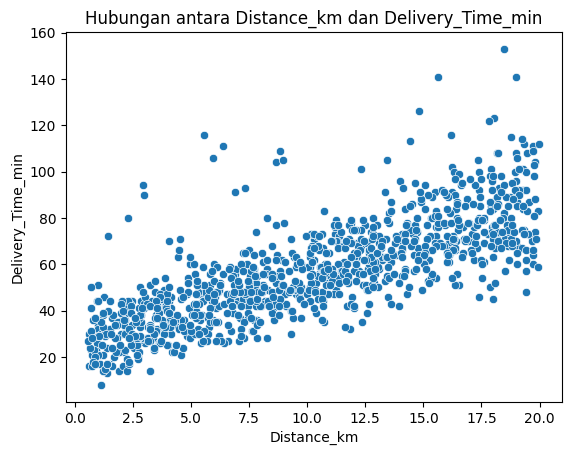

In [24]:
# Scatter plot to see the relationship between features with Delivery_Time_min
sns.scatterplot(x=df['Distance_km'], y=df['Delivery_Time_min'])
plt.title("Hubungan antara Distance_km dan Delivery_Time_min")
plt.show()

1. Strong Positive Relationships: There is a clear positive relationship between delivery distance and delivery time. As delivery distance increases, delivery time also tends to increase. This shows that delivery distance is the main factor influencing delivery duration.

2. Trend Consistency: While there are some points that are more spread out, the general trend shows that the longer the delivery distance, the longer it takes. This is very consistent with the previous analysis that delivery distance contributes greatly to delivery time.

3. Fluctuations over Shorter Distances: Over short distances (less than 5 km), there is more fluctuation in delivery times, which can be caused by other factors such as traffic conditions, time of day, or operational issues.

4. Consistency across Distances: Over longer distances (over 10 km), delivery times seemed more consistent, although there were some spots that were slightly higher. This shows that delivery over long distances is relatively more predictable, although external conditions can still influence it.

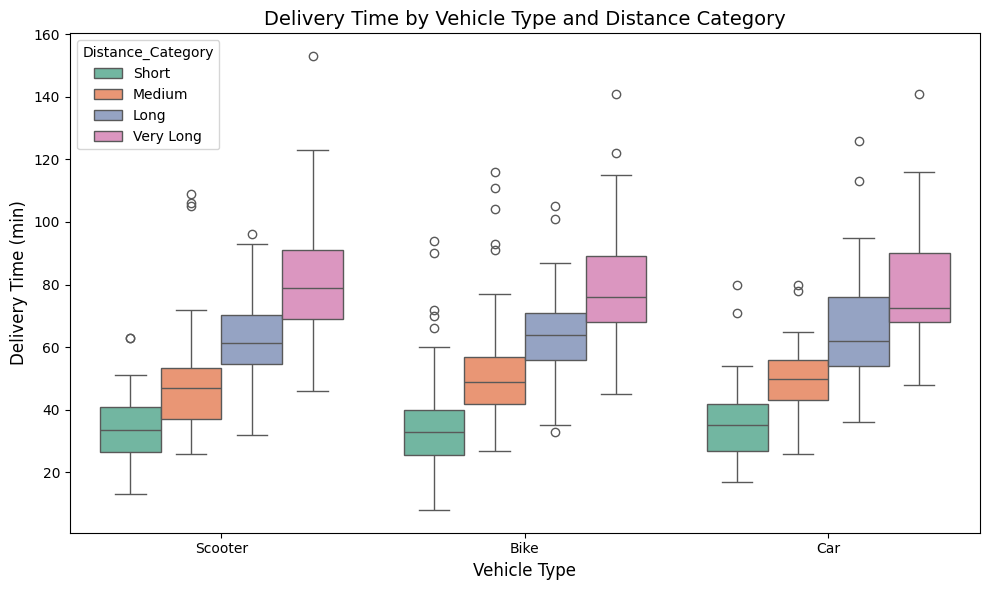

In [25]:
# Convert Distance_km into categorical bins to make visualization clearer
df['Distance_Category'] = pd.qcut(df['Distance_km'], q=4, labels=['Short', 'Medium', 'Long', 'Very Long'])

# Visualize Delivery Time by Vehicle Type and Distance Category using a boxplot
plt.figure(figsize=(10, 6))

sns.boxplot(x='Vehicle_Type', y='Delivery_Time_min', hue='Distance_Category', data=df, palette='Set2')

# Titles and labels
plt.title('Delivery Time by Vehicle Type and Distance Category', fontsize=14)
plt.xlabel('Vehicle Type', fontsize=12)
plt.ylabel('Delivery Time (min)', fontsize=12)

# Show plot
plt.tight_layout()
plt.show()

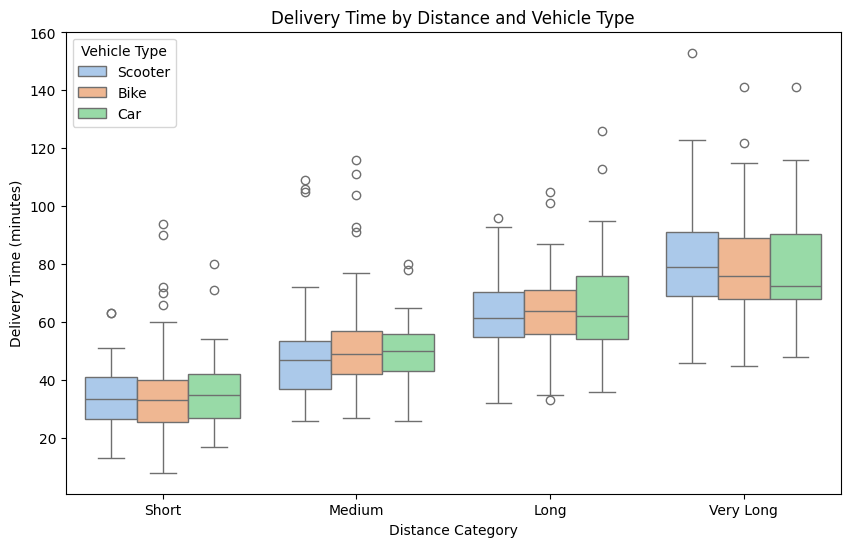

In [26]:
plt.figure(figsize=(10, 6))

# Add the line to create the 'Distance_Category' column
df['Distance_Category'] = pd.qcut(df['Distance_km'], q=4, labels=['Short', 'Medium', 'Long', 'Very Long'])

sns.boxplot(data=df, x='Distance_Category', y='Delivery_Time_min', hue='Vehicle_Type', palette='pastel')
plt.title('Delivery Time by Distance and Vehicle Type')
plt.ylabel('Delivery Time (minutes)')
plt.xlabel('Distance Category')
plt.legend(title='Vehicle Type')
plt.show()

* Vehicle_Type :
1. Scooter = 0
2. Bike = 1
3. Car = 2
* Distance Category
1. Short: 0.59 km – 5.105 km
2. Medium: 5.105 km – 10.19 km
3. Long: 10.19 km – 15.018 km
4. Very Long: 15.018 km – 19.99 km

<ipython-input-27-cecc92cbe27e>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Vehicle_Type', y='Delivery_Time_min', palette='Set2') # Changed 'Time_taken (min)' to 'Delivery_Time_min'


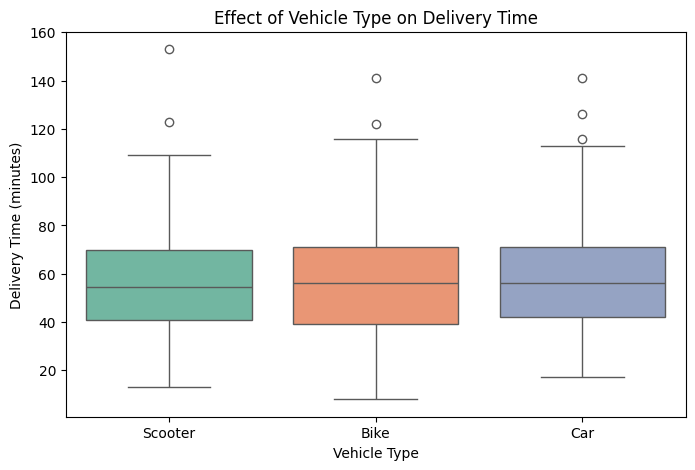

In [27]:
# Boxplot: Jenis Kendaraan vs Waktu Pengantaran
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Vehicle_Type', y='Delivery_Time_min', palette='Set2') # Changed 'Time_taken (min)' to 'Delivery_Time_min'
plt.title('Effect of Vehicle Type on Delivery Time')
plt.ylabel('Delivery Time (minutes)')
plt.xlabel('Vehicle Type')
plt.show()

Boxplot ini akan memberikan pemahaman visual terhadap pengaruh jenis kendaraan dan jarak terhadap waktu pengantaran makanan.



# Data Preparation

In [28]:
# Handle missing values for numerical columns
numerical_columns = ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']
df[numerical_columns] = df[numerical_columns].fillna(df[numerical_columns].median())

In [29]:
# Handle missing values for categorical columns
categorical_columns = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']
df[categorical_columns] = df[categorical_columns].fillna(df[categorical_columns].mode().iloc[0])

In [30]:
# Handle missing values
# Identify columns with missing values
missing_values = df.isnull().sum()
print(missing_values)

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
Distance_Category         0
dtype: int64


In [31]:
df.info(), df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   Order_ID                1000 non-null   int64   
 1   Distance_km             1000 non-null   float64 
 2   Weather                 1000 non-null   object  
 3   Traffic_Level           1000 non-null   object  
 4   Time_of_Day             1000 non-null   object  
 5   Vehicle_Type            1000 non-null   object  
 6   Preparation_Time_min    1000 non-null   int64   
 7   Courier_Experience_yrs  1000 non-null   float64 
 8   Delivery_Time_min       1000 non-null   int64   
 9   Distance_Category       1000 non-null   category
dtypes: category(1), float64(2), int64(3), object(4)
memory usage: 71.6+ KB


(None,
           Order_ID  Distance_km  Preparation_Time_min  Courier_Experience_yrs  \
 count  1000.000000  1000.000000           1000.000000             1000.000000   
 mean    500.500000    10.059970             16.982000                4.592000   
 std     288.819436     5.696656              7.204553                2.871198   
 min       1.000000     0.590000              5.000000                0.000000   
 25%     250.750000     5.105000             11.000000                2.000000   
 50%     500.500000    10.190000             17.000000                5.000000   
 75%     750.250000    15.017500             23.000000                7.000000   
 max    1000.000000    19.990000             29.000000                9.000000   
 
        Delivery_Time_min  
 count        1000.000000  
 mean           56.732000  
 std            22.070915  
 min             8.000000  
 25%            41.000000  
 50%            55.500000  
 75%            71.000000  
 max           153.000000  )

In [32]:
# Removing Order_ID in the dataset since it is not needed

df = df[["Distance_km",
         "Weather",
         "Traffic_Level",
         "Time_of_Day",
         "Vehicle_Type",
         "Preparation_Time_min",
         "Courier_Experience_yrs",
         "Delivery_Time_min"
         ]].dropna()

In [33]:
# Separate features and target
X = df.drop(columns=['Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs' ])
y = df['Delivery_Time_min']

In [34]:
# Setting the values of Weather into integers
# Clear = 0
# Windy = 1
# Foggy = 2
# Rainy = 3
# Snowy = 4

df["Weather"] = df["Weather"].map({"Clear": 0, "Windy": 1, "Foggy": 2, "Rainy": 3, "Snowy": 4})

In [35]:
# Setting the values of Time of Day into integers
# Morning = 0
# Afternoon = 1
# Evening = 2
# Night = 3

df["Time_of_Day"] = df["Time_of_Day"].map({"Morning": 0, "Afternoon": 1, "Evening": 2, "Night": 3})

In [36]:
# Setting the values of Traffic Level into integers
# Low = 0
# Medium = 1
# High = 2

df["Traffic_Level"] = df["Traffic_Level"].map({"Low": 0, "Medium": 1, "High": 2})

In [37]:
# Setting the values of Vehicle Type into integers
# Scooter = 0
# Bike = 1
# Car = 2

df["Vehicle_Type"] = df["Vehicle_Type"].map({"Scooter": 0, "Bike": 1, "Car": 2})

In [38]:
# Finalized Dataset

df

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,1,0,1,0,12,1.0,43
1,16.42,0,1,2,1,20,2.0,84
2,9.52,2,0,3,0,28,1.0,59
3,7.44,3,1,1,0,5,1.0,37
4,19.03,0,0,0,1,16,5.0,68
...,...,...,...,...,...,...,...,...
995,8.50,0,2,2,2,13,3.0,54
996,16.28,3,0,0,0,8,9.0,71
997,15.62,4,2,2,0,26,2.0,81
998,14.17,0,0,1,1,8,0.0,55


In [39]:
df. describe()

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,10.059970,1.30200,0.814000,1.125000,0.893000,16.982000,4.592000,56.732000
std,5.696656,1.48425,0.738884,0.977922,0.697164,7.204553,2.871198,22.070915
min,0.590000,0.00000,0.000000,0.000000,0.000000,5.000000,0.000000,8.000000
25%,5.105000,0.00000,0.000000,0.000000,0.000000,11.000000,2.000000,41.000000
50%,10.190000,0.50000,1.000000,1.000000,1.000000,17.000000,5.000000,55.500000
75%,15.017500,3.00000,1.000000,2.000000,1.000000,23.000000,7.000000,71.000000
max,19.990000,4.00000,2.000000,3.000000,2.000000,29.000000,9.000000,153.000000


In [40]:
# Display the shape of the dataset

df.shape

(1000, 8)

In [41]:
# Checking for any missing values

print(df.isnull().sum())

Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64


In [42]:
# Delivery_Time_Min will be the target value and splitting the data

X = df[["Distance_km", "Weather", "Traffic_Level", "Time_of_Day", "Vehicle_Type", "Preparation_Time_min", "Courier_Experience_yrs"]]
y = df["Delivery_Time_min"]

In [43]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modeling

In [52]:
# Initialize and train the ANN model
ann_model = MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu', solver='adam', max_iter=500, random_state=42)
ann_model.fit(X_train, y_train)

# Make predictions on the test set
ann_predictions = ann_model.predict(X_test)

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


# Evaluation

In [51]:
# Evaluate the model
ann_mae = mean_absolute_error(y_test, ann_predictions)
ann_mse = mean_squared_error(y_test, ann_predictions)
ann_rmse = np.sqrt(ann_mse)
ann_r2 = r2_score(y_test, ann_predictions)

print("ANN Model Evaluation:")
print(f"Mean Absolute Error (MAE): {ann_mae}")
print(f"Mean Squared Error (MSE): {ann_mse}")
print(f"Root Mean Squared Error (RMSE): {ann_rmse}")
print(f"R-squared (R2): {ann_r2}")

ANN Model Evaluation:
Mean Absolute Error (MAE): 6.357531197738021
Mean Squared Error (MSE): 85.26374344254846
Root Mean Squared Error (RMSE): 9.233836875456944
R-squared (R2): 0.8097755195511193


# Deployment

## Model Simulation

In [56]:
# Simulate new data for prediction (example)
new_data = pd.DataFrame({
    'Distance_km': [10],
    'Weather': [0],  # Clear
    'Traffic_Level': [1],  # Medium
    'Time_of_Day': [2],  # Evening
    'Vehicle_Type': [2],  # Car
    'Preparation_Time_min': [20],
    'Courier_Experience_yrs': [3]
})

# Make predictions using the trained ANN model
simulated_delivery_time = ann_model.predict(new_data)

print("Simulated Delivery Time:", simulated_delivery_time[0])


Simulated Delivery Time: 57.84903544049978


## Save Model

In [61]:
import joblib
joblib.dump(ann_model, 'ann_delivery_time_model.pkl')

print("Model and preprocessors saved successfully.")


Model and preprocessors saved successfully.
